<a href="https://colab.research.google.com/github/ocalin911/Deep-Learning-Models-of-Mathematical-Physics/blob/Volume-II/Chapter-5-Thermodynamics/Untitled167.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Equation of State for van der Waals fluid**

 We consider the case of a van der Waals fluid with equation of state
$$
cT = \left(P + \frac{a}{V^2}\right)(V-b),
$$
where we use normalized constants $c=1$, $a=3$, and $b=\tfrac{1}{3}$.

We generate $N=300$ synthetic data points $(P_i, V_i, T_i)$ from this equation of state and then use a neural network to recover the underlying relation, as described above.

We plot a few isothermes in both exact and NN state equations.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


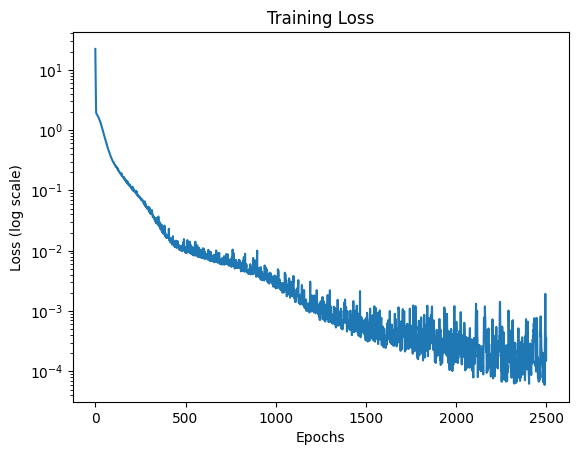

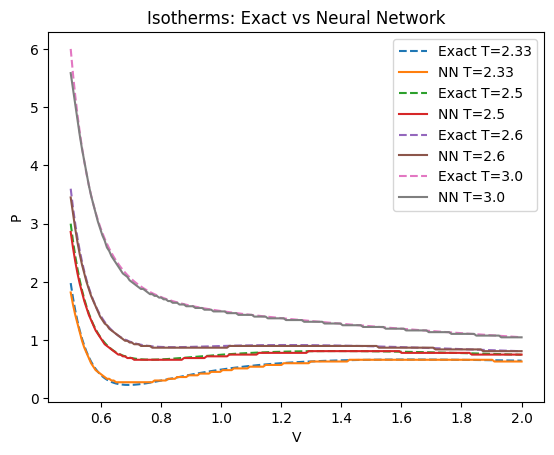

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# =========================
# 1. Parameters
# =========================
N = 300
a, b, c = 3.0, 1.0/3.0, 1.0

# =========================
# 2. Generate synthetic data
# =========================
np.random.seed(0)

P = np.random.uniform(0.1, 6.0, (N,1))
V = np.random.uniform(0.5, 2.0, (N,1))

# EOS: cT = (P + a/V^2)(V - b)
T = (P + a / V**2) * (V - b) / c

X = np.hstack([P, V])
y = T

# =========================
# 3. Build neural network
# =========================
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='tanh', input_shape=(2,)),
    tf.keras.layers.Dense(64, activation='tanh'),
    tf.keras.layers.Dense(1)
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
              loss='mse')

# =========================
# 4. Train
# =========================
history = model.fit(X, y, epochs=2500, verbose=0)

# =========================
# 5. Plot loss
# =========================
plt.figure()
plt.plot(history.history['loss'])
plt.yscale('log')
plt.xlabel("Epochs")
plt.ylabel("Loss (log scale)")
plt.title("Training Loss")
plt.show()

# =========================
# 6. Compare isotherms
# =========================
V_grid = np.linspace(0.5, 2.0, 200)

T_values = [2.33, 2.5, 2.6, 3.0]

plt.figure()

for T0 in T_values:

    # Exact isotherm: solve for P
    P_exact = c*T0/(V_grid - b) - a/(V_grid**2)

    # Neural network prediction
    P_pred = []
    for v in V_grid:
        # solve NN(P,v)=T0 via simple search
        P_candidates = np.linspace(0.1, 6.0, 200)
        PV = np.stack([P_candidates, np.full_like(P_candidates, v)], axis=1)
        T_pred = model.predict(PV, verbose=0).flatten()
        idx = np.argmin(np.abs(T_pred - T0))
        P_pred.append(P_candidates[idx])

    P_pred = np.array(P_pred)

    # Plot
    plt.plot(V_grid, P_exact, '--', label=f'Exact T={T0}')
    plt.plot(V_grid, P_pred, '-', label=f'NN T={T0}')

plt.xlabel("V")
plt.ylabel("P")
plt.title("Isotherms: Exact vs Neural Network")
plt.legend()
plt.show()